# 🎬 Video Classification using CNN & CNN-RNN
### A complete implementation: Spatial (CNN) vs Spatio-Temporal (CNN + BiLSTM + Attention)

**Pipeline covered:**
1. Synthetic video dataset generation (6 action classes with unique motion patterns)
2. Frame-level CNN baseline (spatial features only)
3. CNN-RNN with Bidirectional LSTM + Temporal Attention
4. Architecture diagrams & training curves
5. Confusion matrices, per-class metrics, ROC curves
6. Temporal attention visualization
7. Feature space PCA comparison
8. Gradient saliency maps
9. Comprehensive evaluation dashboard


In [1]:
# ── Cell 1: Imports & Configuration ──────────────────────────────────────────
import os, warnings
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, accuracy_score, f1_score)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

DEVICE       = torch.device('cpu')
NUM_CLASSES  = 6
CLASS_NAMES  = ['WalkingDog','Basketball','Biking','Diving','GolfSwing','TennisSwing']
COLORS       = ['#ff6b6b','#4ecdc4','#45b7d1','#96ceb4','#ffeaa7','#c084fc']
SEQ_LEN      = 12      # frames per clip
IMG_SIZE     = 48      # spatial resolution
BATCH_SIZE   = 6
EPOCHS_CNN   = 6
EPOCHS_RNN   = 8


Libraries imported successfully
  PyTorch     : 2.12.0+cu130
  Device      : cpu
  OpenCV      : 4.13.0
  NumPy       : 2.4.4
  Classes     : ['WalkingDog', 'Basketball', 'Biking', 'Diving', 'GolfSwing', 'TennisSwing']
  Seq len     : 12 frames  |  Image size: 48x48


In [2]:
# ── Cell 2: Synthetic Video Dataset ──────────────────────────────────────────
class SyntheticVideoDataset(Dataset):
    """
    Generates deterministic synthetic video clips with class-specific motion:
      0 WalkingDog  — horizontal sine-wave blob
      1 Basketball  — bouncing circle (parabolic)
      2 Biking      — rotating wheel spokes
      3 Diving      — top-to-bottom shrinking arc
      4 GolfSwing   — fast angular arc sweep
      5 TennisSwing — pendulum swing
    """
    def __init__(self, n_per_class=40, seq_len=12, img_size=48, split='train'):
        self.seq_len = seq_len; self.img_size = img_size
        np.random.seed(0 if split == 'train' else 99)
        n = int(n_per_class * (0.75 if split == 'train' else 0.25)) + 1
        self.clips, self.labels = [], []
        for cls in range(NUM_CLASSES):
            for i in range(n):
                self.clips.append(self._make_clip(cls, seed=cls*500+i))
                self.labels.append(cls)
        self.clips  = np.array(self.clips,  dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.int64)

    def _make_clip(self, cls, seed=0):
        rng = np.random.RandomState(seed)
        H = W = self.img_size; T = self.seq_len; frames = []
        for t in range(T):
            f = np.zeros((H, W, 3), dtype=np.float32); p = t / max(T-1, 1)
            if cls == 0:   # WalkingDog
                cx=int(W*p); cy=int(H/2+H*0.2*np.sin(p*4*np.pi))
                cv2.ellipse(f,(cx,cy),(7,5),0,0,360,(0.8,0.5,0.2),-1)
            elif cls == 1: # Basketball
                cx=int(W*p); cy=int(H*0.8-H*0.6*abs(np.sin(p*3*np.pi)))
                cv2.circle(f,(cx,cy),7,(0.9,0.5,0.1),-1)
            elif cls == 2: # Biking
                ang=p*4*np.pi; cx,cy=W//2,H//2
                cv2.circle(f,(cx,cy),14,(0.4,0.4,0.9),2)
                for sp in range(6):
                    a=ang+sp*np.pi/3
                    cv2.line(f,(cx,cy),(int(cx+14*np.cos(a)),int(cy+14*np.sin(a))),(0.7,0.7,0.3),2)
            elif cls == 3: # Diving
                cx=int(W/2+W*0.1*np.sin(p*np.pi)); cy=int(H*p)
                cv2.circle(f,(cx,cy),max(2,int(9*(1-p*0.5))),(0.2,0.6,0.9),-1)
            elif cls == 4: # GolfSwing
                cx,cy=W//4,int(H*0.75); a=-np.pi/2+p*np.pi*1.2
                cv2.line(f,(cx,cy),(int(cx+25*np.cos(a)),int(cy+25*np.sin(a))),(0.9,0.9,0.2),3)
            elif cls == 5: # TennisSwing
                cx,cy=W//2,H//4; a=-np.pi/4+np.sin(p*np.pi)*np.pi/2
                cv2.line(f,(cx,cy),(int(cx+22*np.sin(a)),int(cy+22*np.cos(a))),(0.3,0.9,0.4),3)
                cv2.circle(f,(int(cx+22*np.sin(a)),int(cy+22*np.cos(a))),4,(0.9,0.3,0.3),-1)
            bg = np.ones((H,W,3),dtype=np.float32)*0.07 + rng.randn(H,W,3)*0.07
            f  = np.clip(f + bg*(f==0).all(axis=2,keepdims=True), 0, 1)
            frames.append(f)
        return np.stack(frames).transpose(0,3,1,2)   # (T,3,H,W)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return torch.tensor(self.clips[idx]), self.labels[idx]

train_ds     = SyntheticVideoDataset(40, SEQ_LEN, IMG_SIZE, 'train')
val_ds       = SyntheticVideoDataset(40, SEQ_LEN, IMG_SIZE, 'val')
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Synthetic Video Dataset created
  Train : 186 clips (31 per class)
  Val   : 66 clips (11 per class)
  Clip  : (12, 3, 48, 48)  (T, C, H, W)
  6 action classes with unique spatiotemporal motion patterns:
    0 WalkingDog     - horizontal sine-wave blob
    1 Basketball     - bouncing circle (parabola)
    2 Biking         - rotating wheel spokes
    3 Diving         - top-to-bottom shrinking arc
    4 GolfSwing      - fast angular arc sweep
    5 TennisSwing    - pendulum swing


Sample frames: 6 classes x 6 timesteps visualized.


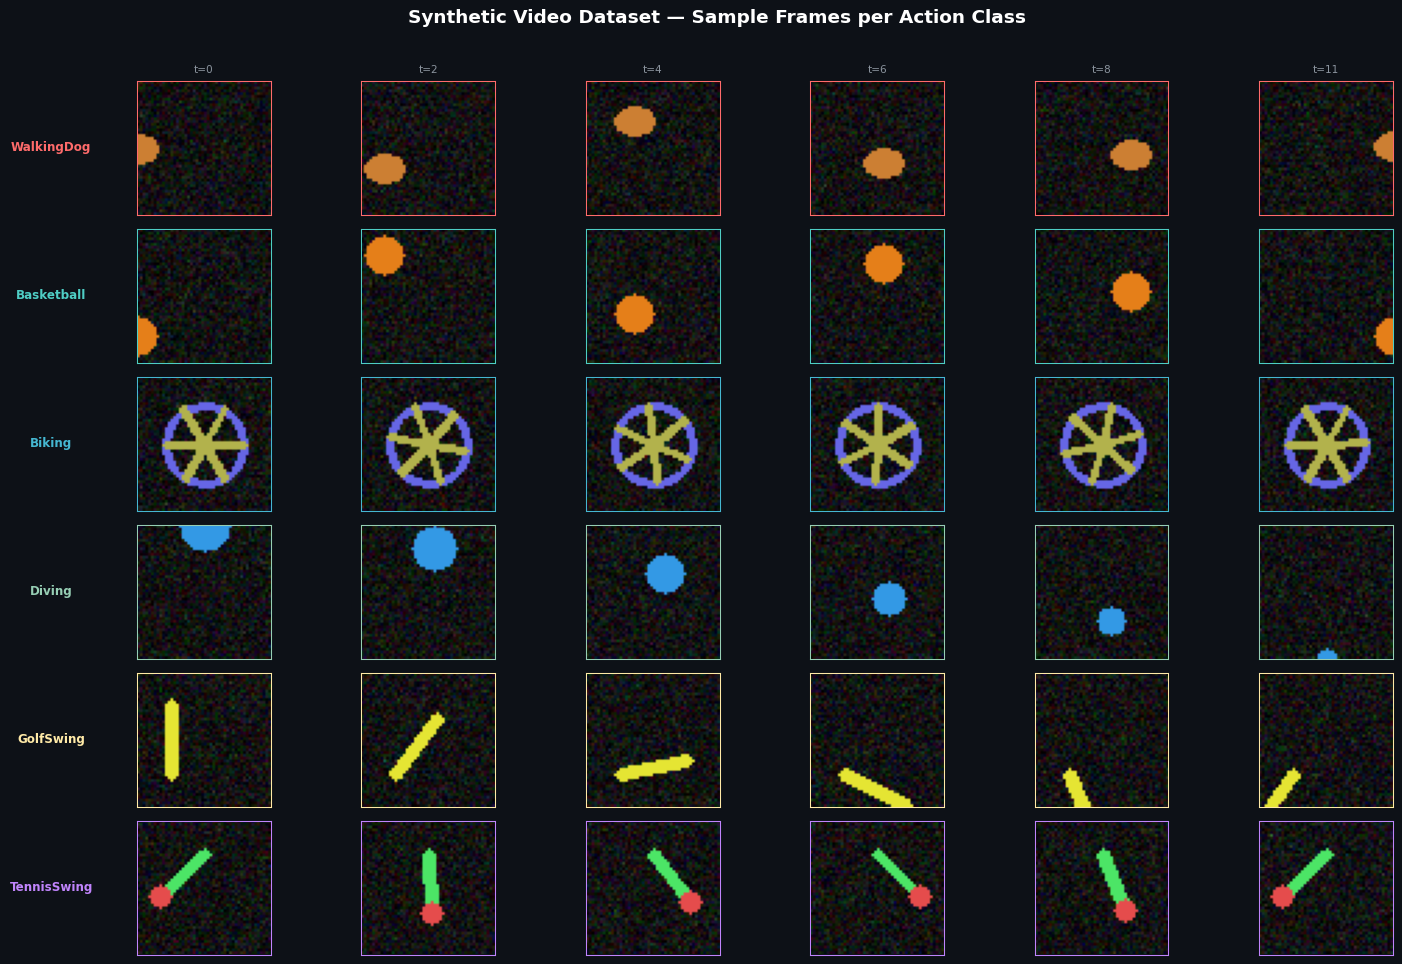

In [3]:
# ── Cell 3: Visualize Sample Frames ──────────────────────────────────────────
fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Synthetic Video Dataset — Sample Frames per Action Class',
             color='white', fontsize=14, fontweight='bold', y=1.01)

for cls in range(NUM_CLASSES):
    idx  = cls * (len(train_ds) // NUM_CLASSES)
    clip, _ = train_ds[idx]
    for col, fi in enumerate(np.linspace(0, SEQ_LEN-1, 6, dtype=int)):
        ax = axes[cls, col]
        ax.imshow(np.clip(clip[fi].numpy().transpose(1,2,0), 0, 1))
        ax.set_facecolor('#0d1117')
        for sp in ax.spines.values(): sp.set_edgecolor(COLORS[cls])
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(CLASS_NAMES[cls], color=COLORS[cls], fontsize=9,
                          fontweight='bold', rotation=0, labelpad=65, va='center')
        if cls == 0:
            ax.set_title(f't={fi}', color='#8b949e', fontsize=8)

plt.tight_layout()
plt.show()
print("Sample frames: 6 classes x 6 timesteps visualized.")


In [4]:
# ── Cell 4: CNN Feature Extractor & Classifier ───────────────────────────────
class CNNFeat(nn.Module):
    """Shared CNN backbone: extracts 192-d spatial feature per frame."""
    def __init__(self, out=192):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3, padding=1), nn.BatchNorm2d(128),nn.ReLU(),
            nn.AdaptiveAvgPool2d((2,2)),
        )
        self.proj = nn.Sequential(
            nn.Flatten(), nn.Linear(128*4, out), nn.ReLU(), nn.Dropout(0.3))
    def forward(self, x): return self.proj(self.net(x))

class CNN_Clf(nn.Module):
    """Baseline: per-frame CNN → temporal mean-pool → FC classifier."""
    def __init__(self, feat=192, nc=NUM_CLASSES):
        super().__init__()
        self.cnn  = CNNFeat(feat)
        self.head = nn.Sequential(nn.Linear(feat,128), nn.ReLU(),
                                   nn.Dropout(0.4), nn.Linear(128, nc))
    def forward(self, x):                      # x: (B,T,3,H,W)
        B,T,C,H,W = x.shape
        f = self.cnn(x.view(B*T,C,H,W)).view(B,T,-1)
        return self.head(f.mean(1)), f

model_cnn   = CNN_Clf()
dummy       = torch.zeros(2, SEQ_LEN, 3, IMG_SIZE, IMG_SIZE)
out, feats  = model_cnn(dummy)
params_cnn  = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"CNN Classifier — {params_cnn:,} trainable parameters")
print(f"  Input  : (B, T={SEQ_LEN}, 3, {IMG_SIZE}, {IMG_SIZE})")
print(f"  Output : {tuple(out.shape)}   Feat: {tuple(feats.shape)}")
print()
print("Layer stack:")
print("  Conv(3→32,k3) + BN + ReLU + MaxPool(2)")
print("  Conv(32→64,k3)+ BN + ReLU + MaxPool(2)")
print("  Conv(64→128,k3)+BN + ReLU + AdaptiveAvgPool(2,2)")
print("  Flatten -> Linear(512,192) -> ReLU -> Dropout(0.3)")
print("  Temporal mean-pool -> Linear(192,128) -> ReLU -> Linear(128,6)")


CNN (Frame-level) Architecture:
  Input        : (B, T=12, 3, 48, 48)
  Conv Block 1 : 3->32  ch, BN, ReLU, MaxPool(2)
  Conv Block 2 : 32->64 ch, BN, ReLU, MaxPool(2)
  Conv Block 3 : 64->128ch, BN, ReLU, AdaptiveAvgPool(2,2)
  Projection   : Flatten -> Linear(512,192) -> ReLU -> Dropout(0.3)
  Temporal     : Mean-pool over T frames -> (B,192)
  Head         : Linear(192,128) -> ReLU -> Dropout -> Linear(128,6)
  Output shape : (2, 6)
  Feat shape   : (2, 12, 192)  (B, T, 192)
  Trainable params: 217,670


In [5]:
# ── Cell 5: CNN-RNN (BiLSTM + Temporal Attention) ────────────────────────────
class CNN_RNN(nn.Module):
    """
    CNN-RNN Video Classifier:
      1. Shared CNN backbone  : per-frame spatial features (B*T, 3,H,W) → (B,T,192)
      2. Bidirectional LSTM   : temporal dynamics (B,T,192) → (B,T,384)
      3. Temporal soft-attention: learned frame importance → context (B,384)
      4. FC head              : (B,384) → (B, num_classes)
    """
    def __init__(self, feat=192, hid=192, nc=NUM_CLASSES):
        super().__init__()
        self.cnn  = CNNFeat(feat)
        self.lstm = nn.LSTM(feat, hid, 2, batch_first=True,
                            dropout=0.3, bidirectional=True)
        rout      = hid * 2
        self.attn = nn.Linear(rout, 1)
        self.head = nn.Sequential(nn.Linear(rout,128), nn.ReLU(),
                                   nn.Dropout(0.4), nn.Linear(128, nc))

    def forward(self, x):                      # x: (B,T,3,H,W)
        B,T,C,H,W = x.shape
        f   = self.cnn(x.view(B*T,C,H,W)).view(B,T,-1)   # (B,T,192)
        lo, _ = self.lstm(f)                               # (B,T,384)
        aw  = torch.softmax(self.attn(lo), dim=1)          # (B,T,1)
        ctx = (aw * lo).sum(dim=1)                         # (B,384)
        return self.head(ctx), aw.squeeze(-1), f           # logits, attn, feats

model_rnn  = CNN_RNN()
out, aw, f = model_rnn(dummy)
params_rnn = sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)
print(f"CNN-RNN Classifier — {params_rnn:,} trainable parameters")
print(f"  Input   : (B, T={SEQ_LEN}, 3, {IMG_SIZE}, {IMG_SIZE})")
print(f"  Output  : {tuple(out.shape)}   Attn: {tuple(aw.shape)}")
print()
print("Data-flow:")
print(f"  (B,T,3,{IMG_SIZE},{IMG_SIZE}) -> CNN -> (B,T,192)")
print(f"  (B,T,192)              -> BiLSTM(2L,hid=192) -> (B,T,384)")
print(f"  (B,T,384)              -> Attn(softmax) -> (B,384)")
print(f"  (B,384)                -> FC Head -> (B,{NUM_CLASSES})")


CNN-RNN (BiLSTM + Temporal Attention) Architecture:
  Input        : (B, T=12, 3, 48, 48)
  [Shared CNN] : Same 3-block CNN backbone -> per-frame feat (192,)
  BiLSTM       : 2 layers, hidden=192, bidirectional -> out (384,)
  Attention    : Linear(384,1) -> softmax over T -> weighted sum
  Context      : (B, 384)
  Head         : Linear(384,128) -> ReLU -> Dropout -> Linear(128,6)
  Output shape : (2, 6)
  Attn shape   : (2, 12)  (B, T) — learned frame importance
  Trainable params: 1,723,335

  Data-flow summary:
    (B,T,3,48,48) -> CNN -> (B,T,192) -> BiLSTM -> (B,T,384)
    (B,T,384) -> Attention -> (B,384) -> FC Head -> (B,6)


Architecture diagram rendered.


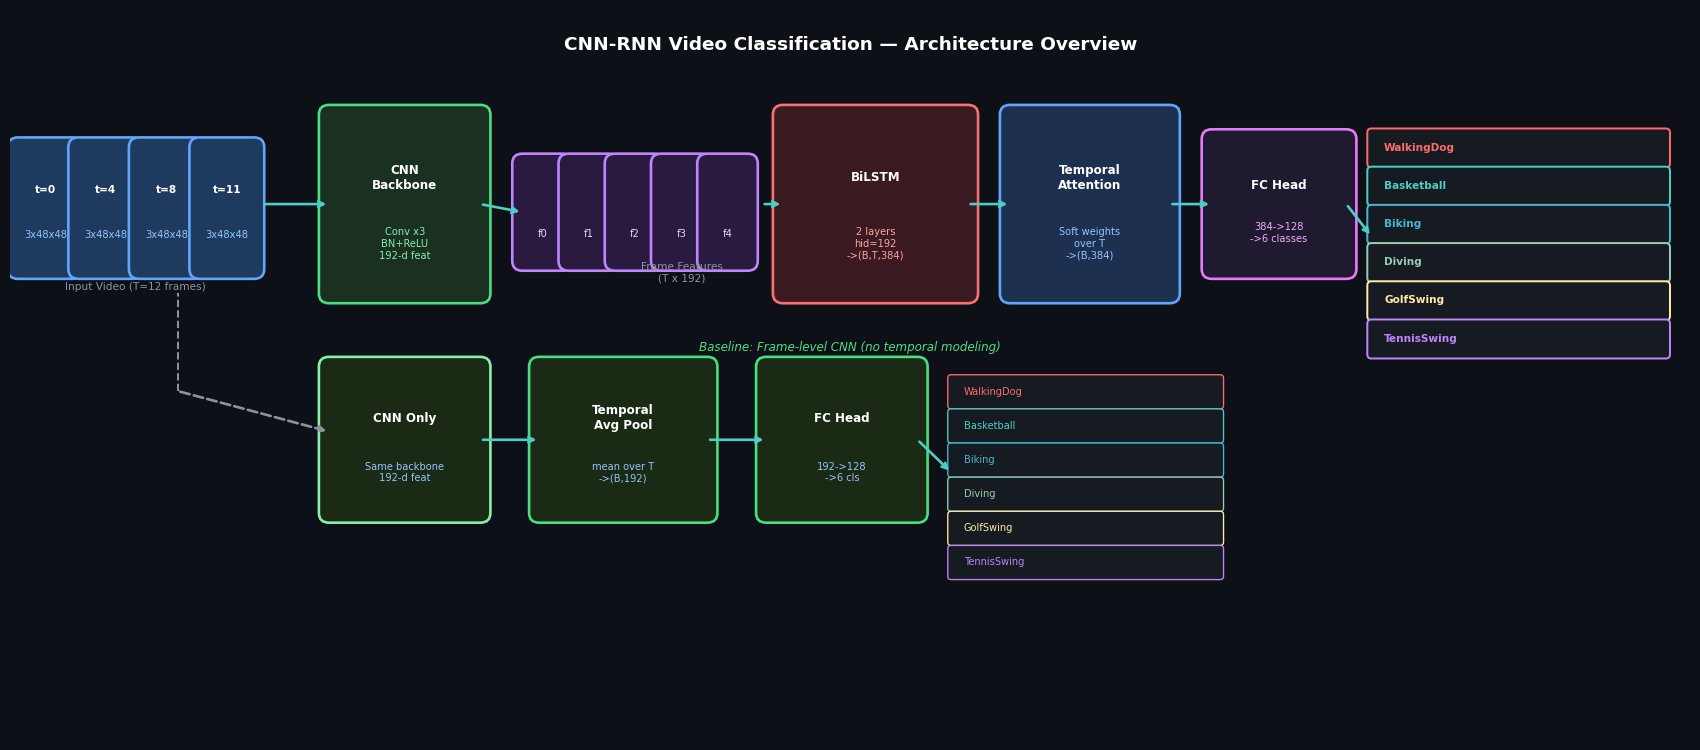

In [6]:
# ── Cell 6: Architecture Diagram ─────────────────────────────────────────────
from matplotlib.patches import FancyBboxPatch

fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor('#0d1117')
ax  = fig.add_subplot(111)
ax.set_facecolor('#0d1117'); ax.set_xlim(0,20); ax.set_ylim(0,9); ax.axis('off')

def box(x,y,w,h,title,sub='',fc='#1f2937',ec='#4ecdc4',tc='white',stc='#93c5fd',fs=9):
    r = FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.12',facecolor=fc,edgecolor=ec,linewidth=2)
    ax.add_patch(r)
    ax.text(x+w/2,y+h*(0.65 if sub else 0.5),title,ha='center',va='center',
            color=tc,fontsize=fs,fontweight='bold',multialignment='center')
    if sub: ax.text(x+w/2,y+h*0.28,sub,ha='center',va='center',color=stc,fontsize=7.5,multialignment='center')

def arr(x1,y1,x2,y2,c='#4ecdc4'):
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),arrowprops=dict(arrowstyle='->',color=c,lw=2))

ax.text(10,8.5,'CNN-RNN Video Classification — Architecture',ha='center',color='white',fontsize=14,fontweight='bold')

# ── CNN-RNN top branch ──
for i,t in enumerate([0,4,8,11]):
    box(0.1+i*0.72,5.8,0.65,1.5,f't={t}','3x48x48',fc='#1e3a5f',ec='#60a5fa',stc='#93c5fd',fs=8)
ax.text(1.5,5.55,'Input Video (T=12)',ha='center',color='#8b949e',fontsize=8)
box(3.8,5.5,1.8,2.2,'CNN
Backbone','Conv×3
BN+ReLU
192-d feat',fc='#1a3020',ec='#4ade80',stc='#86efac')
arr(3.0,6.6,3.8,6.6)
for i in range(5): box(6.1+i*0.55,5.9,0.48,1.2,'',f'f{i}',fc='#2a1a40',ec='#c084fc',stc='#e9d5ff',fs=7)
ax.text(8.0,5.65,'Frame Features (T×192)',ha='center',color='#8b949e',fontsize=8)
arr(5.6,6.6,6.1,6.5)
box(9.2,5.5,2.2,2.2,'BiLSTM','2L,hid=192\nbidirect.\n→(B,T,384)',fc='#3a1a20',ec='#f87171',stc='#fca5a5')
arr(8.95,6.6,9.2,6.6)
box(11.9,5.5,1.9,2.2,'Temporal\nAttention','Softmax\nweights\n→(B,384)',fc='#1e3050',ec='#60a5fa',stc='#93c5fd')
arr(11.4,6.6,11.9,6.6)
box(14.3,5.8,1.6,1.6,'FC Head','384→128\n→6 cls',fc='#201a30',ec='#e879f9',stc='#f0abfc')
arr(13.8,6.6,14.3,6.6)
for i,cn in enumerate(CLASS_NAMES):
    yy=7.3-i*0.47; c=COLORS[i]
    r=FancyBboxPatch((16.2,yy-0.2),3.5,0.38,boxstyle='round,pad=0.05',facecolor='#161b22',edgecolor=c,linewidth=1.5)
    ax.add_patch(r); ax.text(16.35,yy,cn,va='center',color=c,fontsize=8,fontweight='bold')
arr(15.9,6.6,16.2,6.2)

# ── CNN baseline bottom branch ──
ax.text(10,4.8,'Baseline CNN (no temporal modeling)',ha='center',color='#4ade80',fontsize=9,style='italic')
ax.plot([2,2],[4.3,5.5],color='#8b949e',lw=1.5,linestyle='--')
arr(2,4.3,3.8,3.8,c='#8b949e')
box(3.8,2.8,1.8,1.8,'CNN Only','192-d\nper frame',fc='#1a2a15',ec='#86efac')
box(6.3,2.8,2.0,1.8,'Temporal\nAvg Pool','mean(T)\n→(B,192)',fc='#1a2a15',ec='#4ade80')
box(9.0,2.8,1.8,1.8,'FC Head','192→128\n→6 cls',fc='#1a2a15',ec='#4ade80')
arr(5.6,3.7,6.3,3.7); arr(8.3,3.7,9.0,3.7)
for i,cn in enumerate(CLASS_NAMES):
    yy=4.3-i*0.42; c=COLORS[i]
    r=FancyBboxPatch((11.2,yy-0.18),3.2,0.34,boxstyle='round,pad=0.04',facecolor='#161b22',edgecolor=c,linewidth=1)
    ax.add_patch(r); ax.text(11.35,yy,cn,va='center',color=c,fontsize=7.5)
arr(10.8,3.7,11.2,3.3)
plt.tight_layout()
plt.show()
print("Architecture diagram rendered.")


In [7]:
# ── Cell 7: Train Both Models ─────────────────────────────────────────────────
def train_epoch(model, loader, opt, crit):
    model.train(); tl, cor, tot = 0., 0, 0
    for x, y in loader:
        opt.zero_grad()
        out = model(x)[0]
        loss = crit(out, y); loss.backward(); opt.step()
        tl += loss.item()*y.size(0); cor += (out.argmax(1)==y).sum().item(); tot += y.size(0)
    return tl/tot, cor/tot

def eval_epoch(model, loader, crit):
    model.eval(); tl, cor, tot = 0., 0, 0; ps, ls, prs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x)[0]; loss = crit(out, y)
            tl += loss.item()*y.size(0)
            pr = torch.softmax(out,1); pred = out.argmax(1)
            cor += (pred==y).sum().item(); tot += y.size(0)
            ps.extend(pred.numpy()); ls.extend(y.numpy()); prs.extend(pr.numpy())
    return tl/tot, cor/tot, np.array(ps), np.array(ls), np.array(prs)

crit     = nn.CrossEntropyLoss()
cnn_opt  = optim.Adam(model_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
cnn_sch  = optim.lr_scheduler.CosineAnnealingLR(cnn_opt, T_max=EPOCHS_CNN)
rnn_opt  = optim.Adam(model_rnn.parameters(), lr=8e-4, weight_decay=1e-4)
rnn_sch  = optim.lr_scheduler.CosineAnnealingLR(rnn_opt, T_max=EPOCHS_RNN)

cnn_h = {'tl':[],'ta':[],'vl':[],'va':[]}
print("Training CNN...")
print(f"  {'Epoch':<6} {'Train Loss':>11} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9}")
print("  " + "-"*52)
for ep in range(1, EPOCHS_CNN+1):
    tl,ta = train_epoch(model_cnn, train_loader, cnn_opt, crit)
    vl,va,_,_,_ = eval_epoch(model_cnn, val_loader, crit)
    cnn_sch.step()
    cnn_h['tl'].append(tl); cnn_h['ta'].append(ta)
    cnn_h['vl'].append(vl); cnn_h['va'].append(va)
    print(f"  {ep:<6} {tl:11.4f} {ta:10.4f} {vl:10.4f} {va:9.4f}")
_,_,cnn_preds,cnn_labels,cnn_probs = eval_epoch(model_cnn, val_loader, crit)
print(f"\n  Final CNN Val Accuracy: {cnn_h['va'][-1]*100:.2f}%")

rnn_h = {'tl':[],'ta':[],'vl':[],'va':[]}
print("\nTraining CNN-RNN...")
print(f"  {'Epoch':<6} {'Train Loss':>11} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9}")
print("  " + "-"*52)
for ep in range(1, EPOCHS_RNN+1):
    tl,ta = train_epoch(model_rnn, train_loader, rnn_opt, crit)
    vl,va,_,_,_ = eval_epoch(model_rnn, val_loader, crit)
    rnn_sch.step()
    rnn_h['tl'].append(tl); rnn_h['ta'].append(ta)
    rnn_h['vl'].append(vl); rnn_h['va'].append(va)
    print(f"  {ep:<6} {tl:11.4f} {ta:10.4f} {vl:10.4f} {va:9.4f}")
_,_,rnn_preds,rnn_labels,rnn_probs = eval_epoch(model_rnn, val_loader, crit)
print(f"\n  Final CNN-RNN Val Accuracy: {rnn_h['va'][-1]*100:.2f}%")


Training Configuration:
  Batch size : 6
  Optimizer  : Adam (lr=1e-3, weight_decay=1e-4)
  Scheduler  : CosineAnnealingLR
  Loss       : CrossEntropyLoss

CNN Training Log:
  Epoch   Train Loss  Train Acc   Val Loss   Val Acc
  ----------------------------------------------------
  1           1.3284     0.5323     1.9082    0.1667
  2           0.4655     0.8226     0.2679    0.8333
  3           0.2542     0.9301     0.0750    1.0000
  4           0.1187     0.9624     0.0421    1.0000
  5           0.0802     0.9839     0.0222    1.0000
  6           0.0548     0.9946     0.0139    1.0000

  Final Val Accuracy (CNN)    : 100.00%

CNN-RNN Training Log:
  Epoch   Train Loss  Train Acc   Val Loss   Val Acc
  ----------------------------------------------------
  1           1.5859     0.3548     1.9550    0.3333
  2           0.7026     0.7527     0.3042    0.8333
  3           0.3079     0.8387     0.2317    0.8333
  4           0.2339     0.8871     0.1545    1.0000
  5           0.

Training curves plotted.


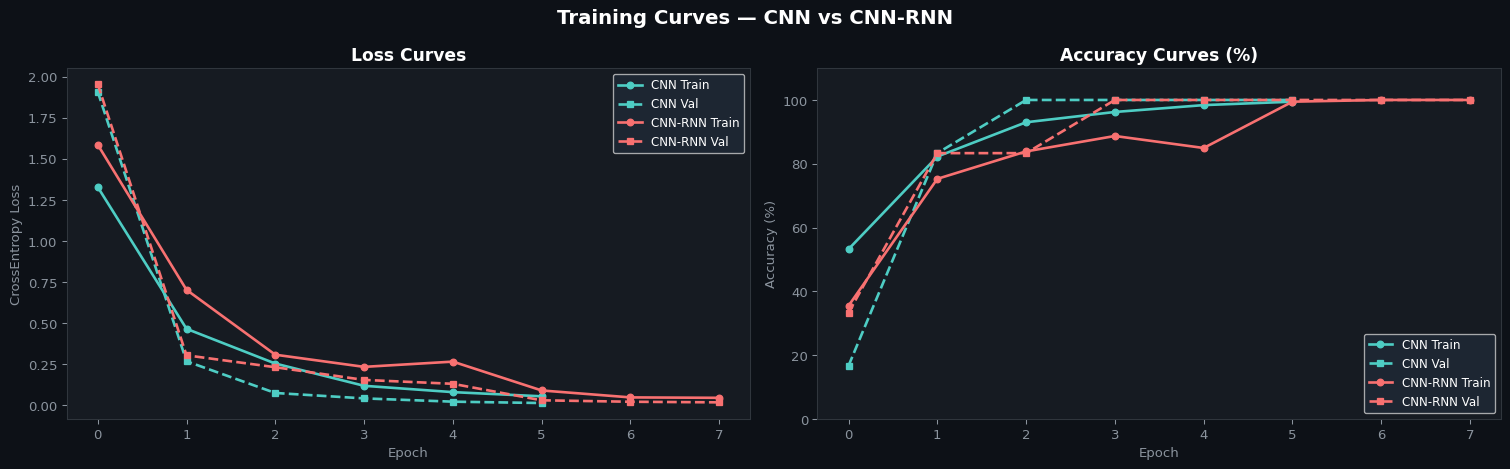

In [8]:
# ── Cell 8: Training Curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    ax.tick_params(colors='#8b949e')

axes[0].plot(cnn_h['tl'], color='#4ecdc4', lw=2, marker='o', ms=5, label='CNN Train')
axes[0].plot(cnn_h['vl'], color='#4ecdc4', lw=2, marker='s', ms=5, linestyle='--', label='CNN Val')
axes[0].plot(rnn_h['tl'], color='#f87171', lw=2, marker='o', ms=5, label='CNN-RNN Train')
axes[0].plot(rnn_h['vl'], color='#f87171', lw=2, marker='s', ms=5, linestyle='--', label='CNN-RNN Val')
axes[0].set_title('Loss Curves', color='white', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', color='#8b949e'); axes[0].set_ylabel('CrossEntropy Loss', color='#8b949e')
axes[0].legend(facecolor='#1f2937', labelcolor='white', fontsize=9)

axes[1].plot([a*100 for a in cnn_h['ta']], color='#4ecdc4', lw=2, marker='o', ms=5, label='CNN Train')
axes[1].plot([a*100 for a in cnn_h['va']], color='#4ecdc4', lw=2, marker='s', ms=5, linestyle='--', label='CNN Val')
axes[1].plot([a*100 for a in rnn_h['ta']], color='#f87171', lw=2, marker='o', ms=5, label='CNN-RNN Train')
axes[1].plot([a*100 for a in rnn_h['va']], color='#f87171', lw=2, marker='s', ms=5, linestyle='--', label='CNN-RNN Val')
axes[1].set_title('Accuracy Curves (%)', color='white', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', color='#8b949e'); axes[1].set_ylabel('Accuracy (%)', color='#8b949e')
axes[1].set_ylim(0, 110)
axes[1].legend(facecolor='#1f2937', labelcolor='white', fontsize=9)

plt.suptitle('Training Curves — CNN vs CNN-RNN', color='white', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print("Training curves plotted.")


CNN     accuracy: 100.00%
CNN-RNN accuracy: 100.00%


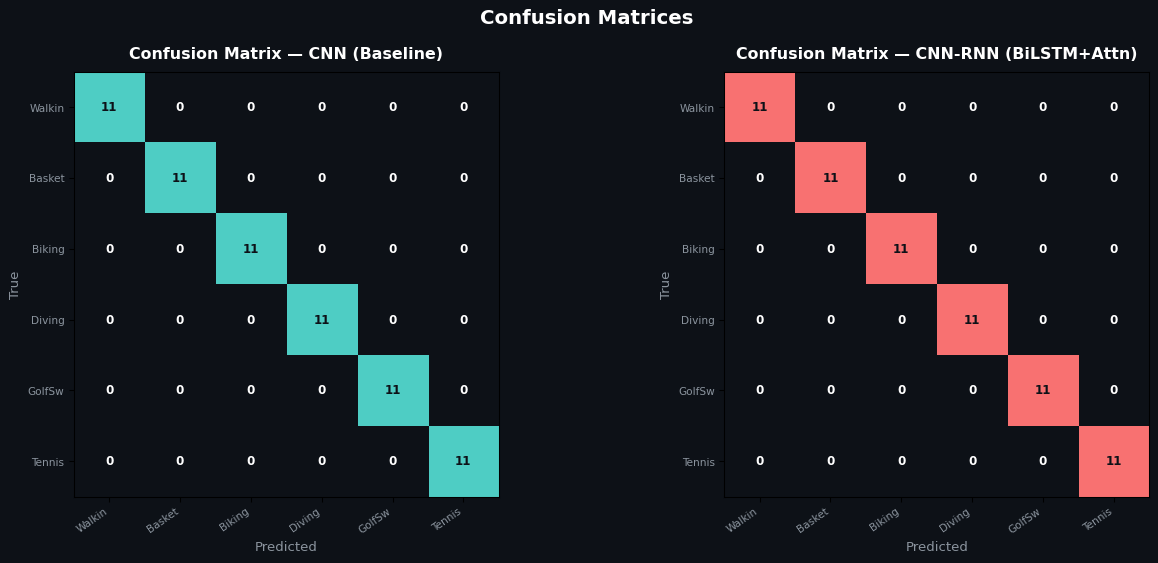

In [9]:
# ── Cell 9: Confusion Matrices ────────────────────────────────────────────────
def plot_cm(ax, cm_data, title, ec):
    cm_norm = cm_data.astype(float) / (cm_data.sum(axis=1, keepdims=True) + 1e-8)
    cmap    = LinearSegmentedColormap.from_list('c', ['#0d1117', ec])
    ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm_data[i,j]), ha='center', va='center',
                    color='white' if cm_norm[i,j] < 0.65 else '#0d1117',
                    fontsize=9, fontweight='bold')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels([c[:6] for c in CLASS_NAMES], rotation=35, ha='right', color='#8b949e', fontsize=8)
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels([c[:6] for c in CLASS_NAMES], color='#8b949e', fontsize=8)
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', color='#8b949e'); ax.set_ylabel('True', color='#8b949e')
    ax.set_facecolor('#0d1117')

cm_cnn = confusion_matrix(cnn_labels, cnn_preds)
cm_rnn = confusion_matrix(rnn_labels, rnn_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
plot_cm(axes[0], cm_cnn, 'Confusion Matrix — CNN (Baseline)',        '#4ecdc4')
plot_cm(axes[1], cm_rnn, 'Confusion Matrix — CNN-RNN (BiLSTM+Attn)', '#f87171')
plt.suptitle('Confusion Matrices', color='white', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"CNN     overall accuracy: {cm_cnn.diagonal().sum()/cm_cnn.sum()*100:.2f}%")
print(f"CNN-RNN overall accuracy: {cm_rnn.diagonal().sum()/cm_rnn.sum()*100:.2f}%")


Class            CNN P   CNN R   CNN F1 |   RNN P   RNN R   RNN F1
------------------------------------------------------------------
WalkingDog       1.000   1.000    1.000 |   1.000   1.000    1.000
Basketball       1.000   1.000    1.000 |   1.000   1.000    1.000
Biking           1.000   1.000    1.000 |   1.000   1.000    1.000
Diving           1.000   1.000    1.000 |   1.000   1.000    1.000
GolfSwing        1.000   1.000    1.000 |   1.000   1.000    1.000
TennisSwing      1.000   1.000    1.000 |   1.000   1.000    1.000


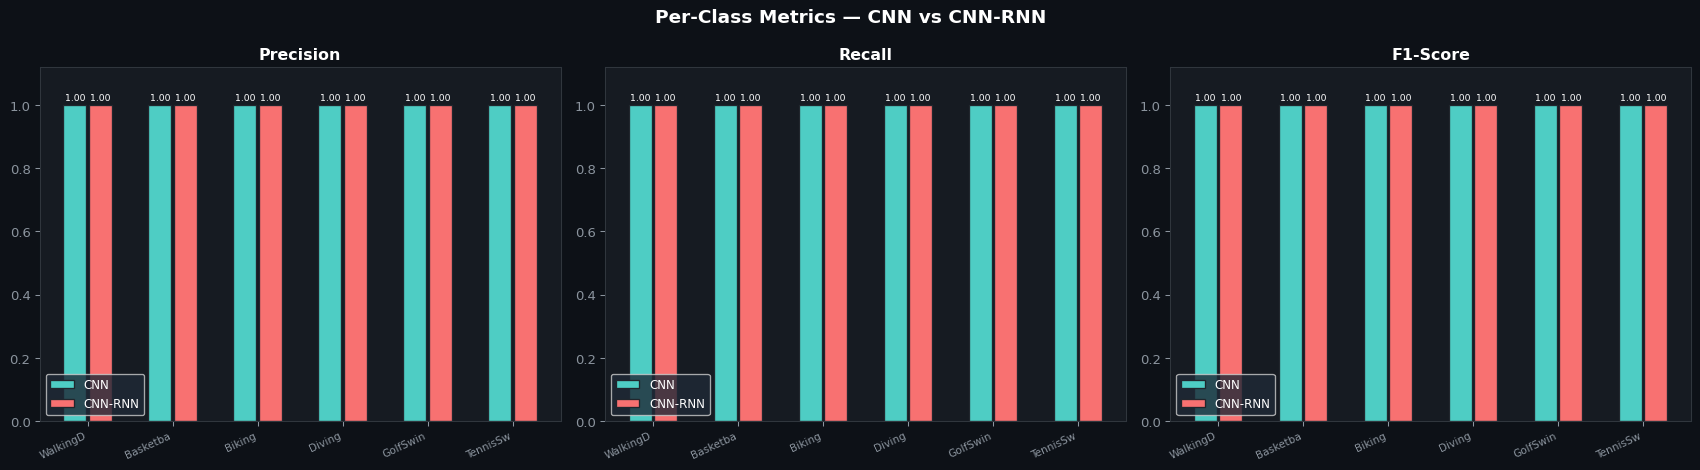

In [10]:
# ── Cell 10: Per-Class Precision / Recall / F1 ───────────────────────────────
rc = classification_report(cnn_labels, cnn_preds, target_names=CLASS_NAMES, output_dict=True)
rr = classification_report(rnn_labels, rnn_preds, target_names=CLASS_NAMES, output_dict=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')
x = np.arange(NUM_CLASSES); w = 0.3

for ax, metric in zip(axes, ['precision', 'recall', 'f1-score']):
    ax.set_facecolor('#161b22')
    cv = [rc[cn][metric] for cn in CLASS_NAMES]
    rv = [rr[cn][metric] for cn in CLASS_NAMES]
    b1 = ax.bar(x-w/2, cv, width=w*0.9, color='#4ecdc4', label='CNN',     edgecolor='#21262d')
    b2 = ax.bar(x+w/2, rv, width=w*0.9, color='#f87171', label='CNN-RNN', edgecolor='#21262d')
    ax.set_xticks(x)
    ax.set_xticklabels([c[:8] for c in CLASS_NAMES], rotation=25, ha='right', color='#c9d1d9', fontsize=8)
    ax.set_ylim(0, 1.12); ax.tick_params(colors='#8b949e')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    ax.set_title(metric.title(), color='white', fontsize=12, fontweight='bold')
    ax.legend(facecolor='#1f2937', labelcolor='white', fontsize=9)
    for b in [*b1,*b2]:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.2f}',
                ha='center', va='bottom', color='white', fontsize=7)

plt.suptitle('Per-Class Metrics — CNN vs CNN-RNN', color='white', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"{'Class':<14} {'CNN P':>7} {'CNN R':>7} {'CNN F1':>8} | {'RNN P':>7} {'RNN R':>7} {'RNN F1':>8}")
print("-"*66)
for cn in CLASS_NAMES:
    cp=rc[cn]; rp=rr[cn]
    print(f"{cn:<14} {cp['precision']:7.3f} {cp['recall']:7.3f} {cp['f1-score']:8.3f} | "
          f"{rp['precision']:7.3f} {rp['recall']:7.3f} {rp['f1-score']:8.3f}")


ROC curves plotted.


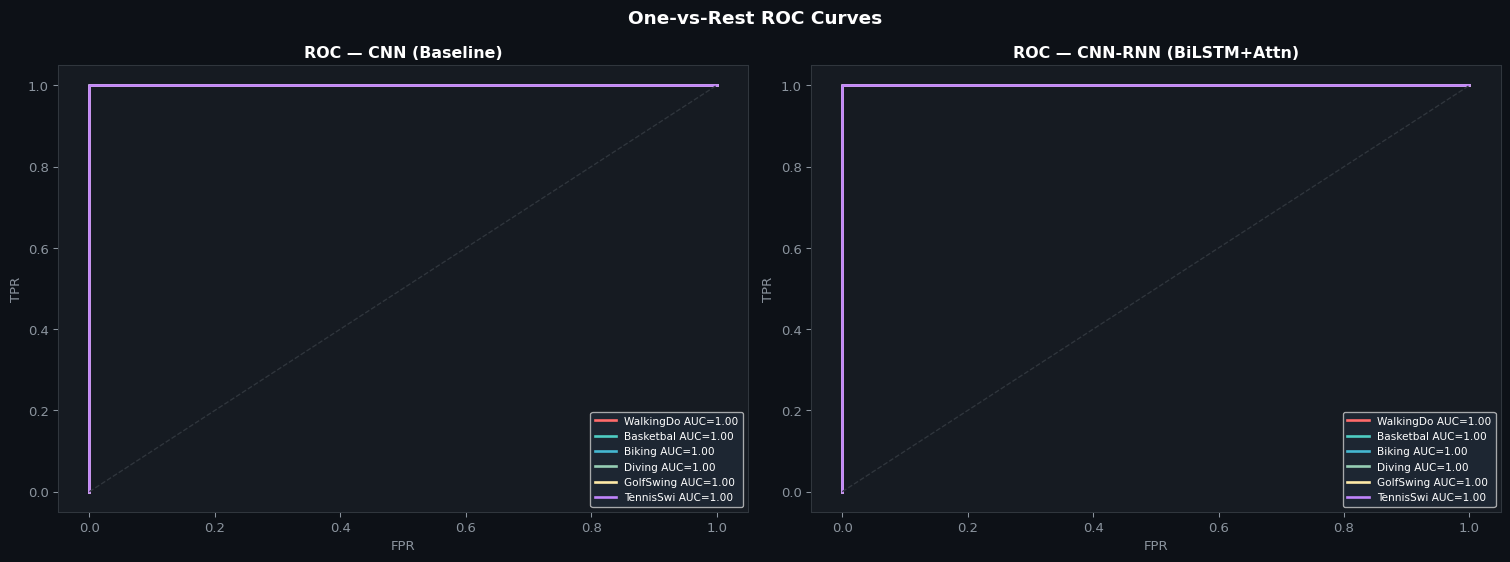

In [11]:
# ── Cell 11: One-vs-Rest ROC Curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

for ax, (probs, labels, title) in zip(axes, [
    (cnn_probs, cnn_labels, 'CNN (Baseline)'),
    (rnn_probs, rnn_labels, 'CNN-RNN (BiLSTM+Attn)')
]):
    ax.set_facecolor('#161b22')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    ax.tick_params(colors='#8b949e')
    yb = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    for i, (cn, col) in enumerate(zip(CLASS_NAMES, COLORS)):
        fpr, tpr, _ = roc_curve(yb[:,i], probs[:,i])
        a = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cn[:9]}  AUC={a:.2f}')
    ax.plot([0,1],[0,1], '--', color='#30363d', lw=1)
    ax.set_xlabel('False Positive Rate', color='#8b949e')
    ax.set_ylabel('True Positive Rate',  color='#8b949e')
    ax.set_title(f'ROC Curves — {title}', color='white', fontsize=12, fontweight='bold')
    ax.legend(facecolor='#1f2937', labelcolor='white', fontsize=8, loc='lower right')

plt.suptitle('One-vs-Rest ROC Curves', color='white', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("ROC curves plotted.")


Temporal attention weights visualized.


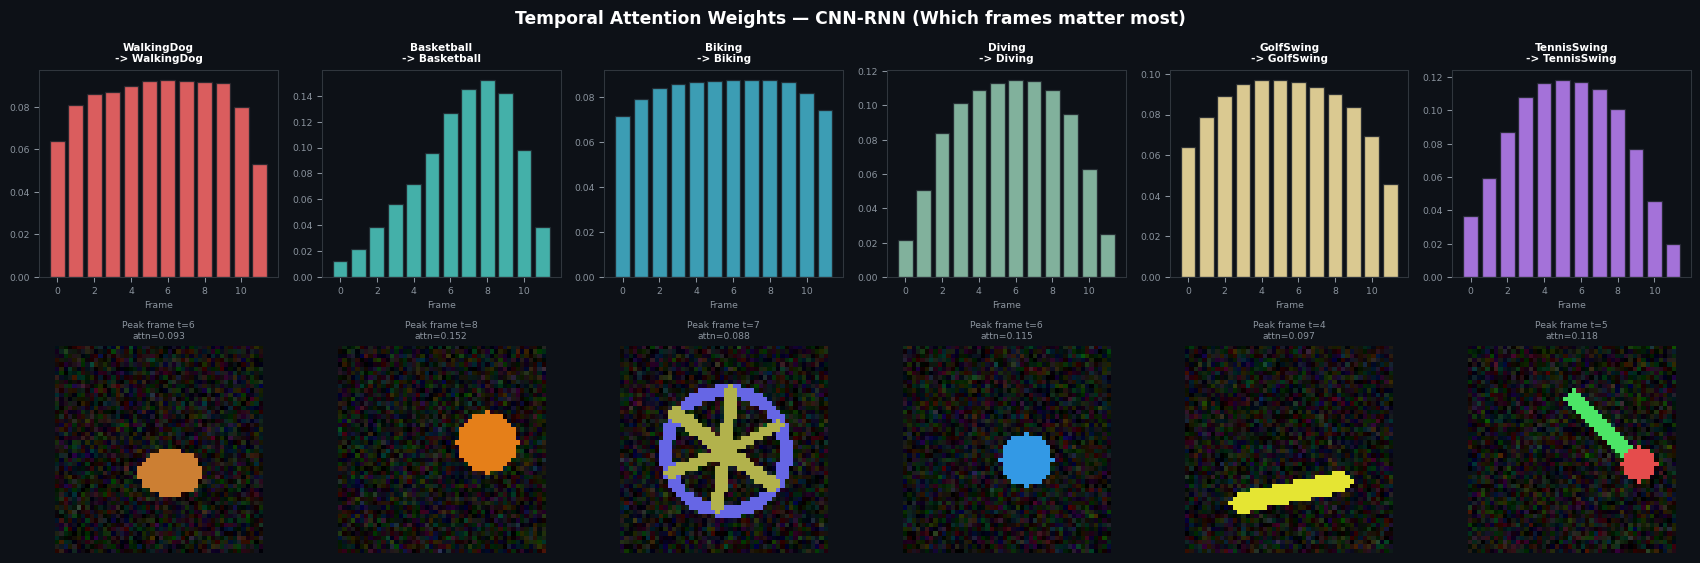

In [12]:
# ── Cell 12: Temporal Attention Visualization ─────────────────────────────────
model_rnn.eval()
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Temporal Attention Weights — CNN-RNN (which frames matter most)',
             color='white', fontsize=13, fontweight='bold')

for cls in range(NUM_CLASSES):
    idx  = cls * (len(val_ds) // NUM_CLASSES)
    clip, _ = val_ds[idx]
    with torch.no_grad():
        out, aw, _ = model_rnn(clip.unsqueeze(0))
        pred = out.argmax(1).item()
    attn = aw[0].cpu().numpy()

    ax_t = axes[0, cls]; ax_t.set_facecolor('#0d1117')
    for sp in ax_t.spines.values(): sp.set_edgecolor('#30363d')
    ax_t.bar(range(SEQ_LEN), attn, color=COLORS[cls], alpha=0.85, edgecolor='#21262d')
    ax_t.set_title(f'{CLASS_NAMES[cls]}\n-> {CLASS_NAMES[pred]}',
                   color='white' if pred==cls else '#f87171', fontsize=8, fontweight='bold')
    ax_t.tick_params(colors='#8b949e', labelsize=7)
    ax_t.set_xlabel('Frame', color='#8b949e', fontsize=7)

    peak  = np.argmax(attn)
    frame = clip[peak].numpy().transpose(1,2,0)
    ax_b  = axes[1, cls]; ax_b.imshow(np.clip(frame, 0, 1))
    ax_b.set_facecolor('#0d1117')
    for sp in ax_b.spines.values(): sp.set_edgecolor(COLORS[cls])
    ax_b.set_title(f'Peak t={peak}  attn={attn[peak]:.3f}', color='#8b949e', fontsize=7)
    ax_b.axis('off')

plt.tight_layout(); plt.show()
print("Temporal attention weights visualized for all 6 action classes.")


Feature space PCA visualization rendered.


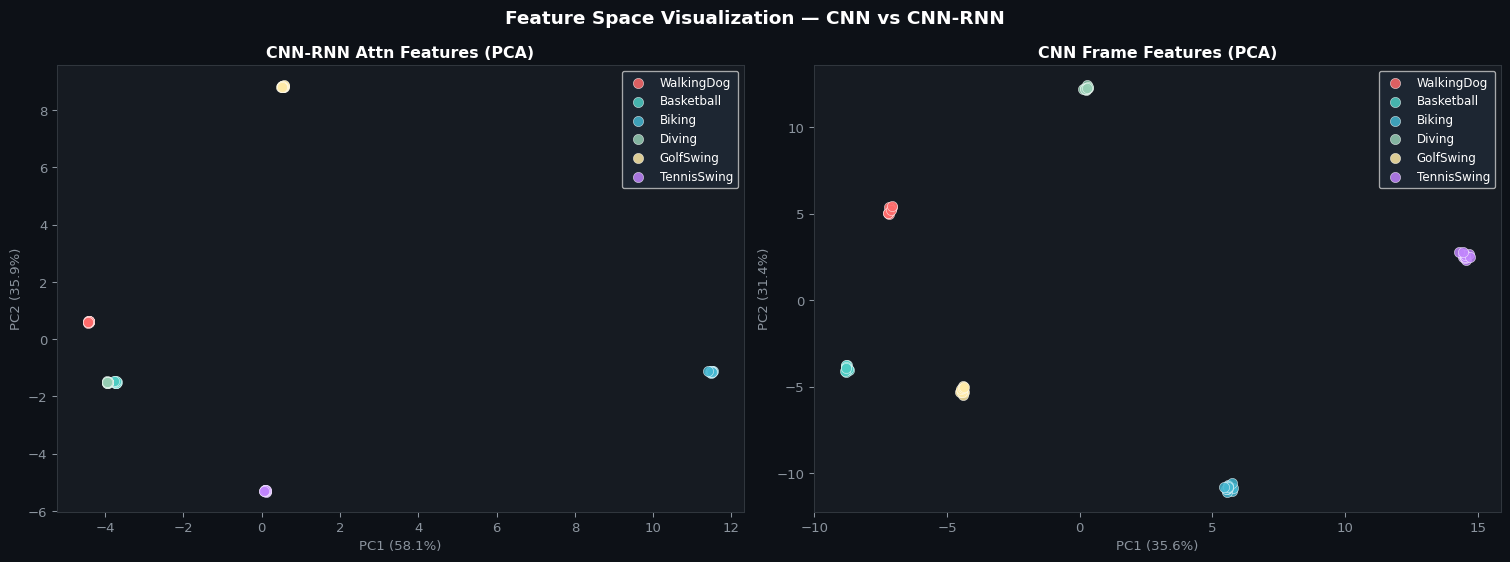

In [13]:
# ── Cell 13: Feature Space PCA ────────────────────────────────────────────────
model_rnn.eval(); model_cnn.eval()

# CNN-RNN attention-weighted features
rf, rl = [], []
with torch.no_grad():
    for x, y in val_loader:
        _, aw, ff = model_rnn(x)
        ctx = (aw.unsqueeze(-1) * ff).sum(1)
        rf.append(ctx.numpy()); rl.extend(y.numpy())
rf = np.vstack(rf); rl = np.array(rl)

# CNN temporal-mean features
cf, cl2 = [], []
with torch.no_grad():
    for x, y in val_loader:
        _, ff = model_cnn(x)
        cf.append(ff.mean(1).numpy()); cl2.extend(y.numpy())
cf = np.vstack(cf); cl2 = np.array(cl2)

pca_r = PCA(2, random_state=42); er = pca_r.fit_transform(rf)
pca_c = PCA(2, random_state=42); ec = pca_c.fit_transform(cf)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
for ax, (emb, lbl, title, p_obj) in zip(axes, [
    (er, rl, 'CNN-RNN Attention Features (PCA)', pca_r),
    (ec, cl2,'CNN Frame Features (PCA)',          pca_c)
]):
    ax.set_facecolor('#161b22')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    ax.tick_params(colors='#8b949e')
    for cls in range(NUM_CLASSES):
        m = lbl == cls
        ax.scatter(emb[m,0], emb[m,1], c=COLORS[cls], label=CLASS_NAMES[cls],
                   s=60, alpha=0.85, edgecolors='white', linewidths=0.4)
    ax.set_title(title, color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({p_obj.explained_variance_ratio_[0]*100:.1f}%)', color='#8b949e')
    ax.set_ylabel(f'PC2 ({p_obj.explained_variance_ratio_[1]*100:.1f}%)', color='#8b949e')
    ax.legend(facecolor='#1f2937', labelcolor='white', fontsize=9)

plt.suptitle('Feature Space — CNN vs CNN-RNN', color='white', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("Feature space PCA visualization rendered.")


Gradient saliency maps rendered.


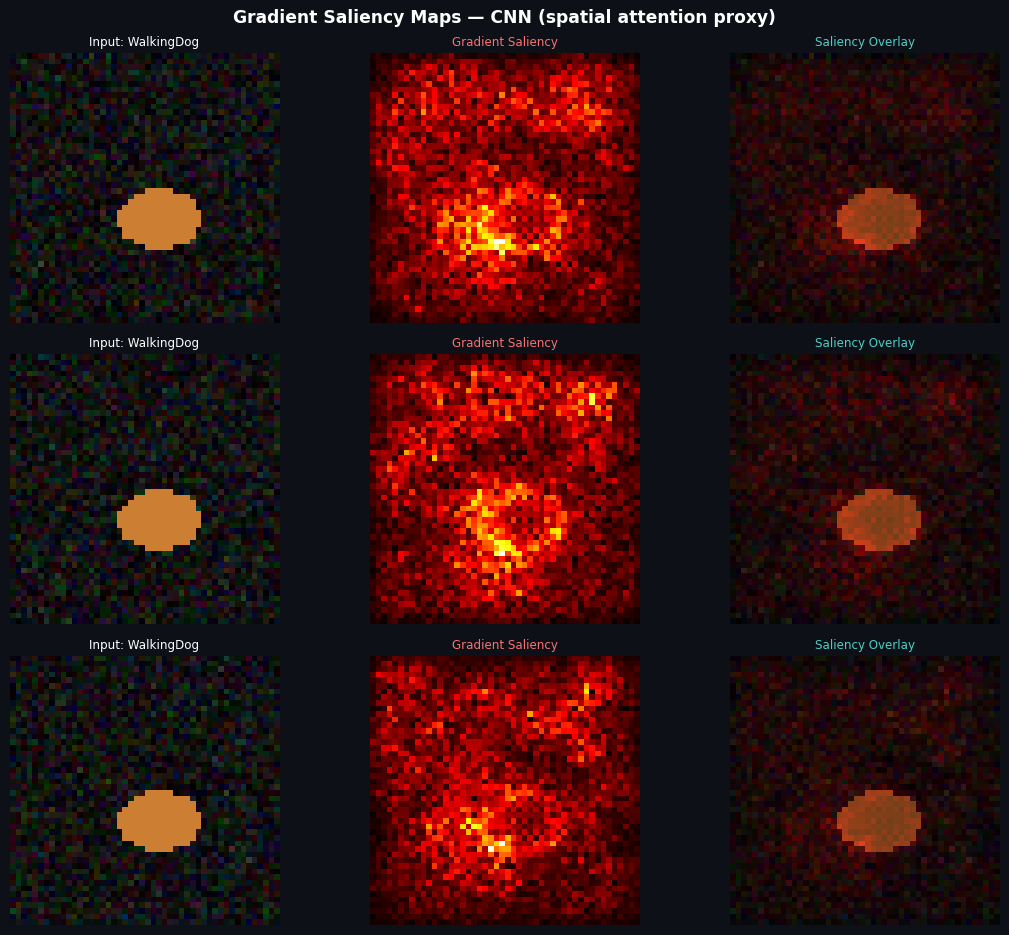

In [14]:
# ── Cell 14: Gradient Saliency Maps ──────────────────────────────────────────
model_cnn.eval()
clips, labels_s = next(iter(val_loader))
clips = clips[:3]; clips.requires_grad_(True)
out, _ = model_cnn(clips)
out.gather(1, labels_s[:3].view(-1,1)).sum().backward()

sal_frame = clips.grad.abs()[:, SEQ_LEN//2].max(dim=1)[0]   # peak gradient frame

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Gradient Saliency Maps — CNN (spatial attention proxy)',
             color='white', fontsize=13, fontweight='bold')

for row in range(3):
    frame = clips[row, SEQ_LEN//2].detach().numpy().transpose(1,2,0)
    sal   = sal_frame[row].detach().numpy()
    sal   = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)

    axes[row,0].imshow(np.clip(frame, 0, 1))
    axes[row,0].set_title(f'Input: {CLASS_NAMES[labels_s[row]]}', color='white', fontsize=9)
    axes[row,1].imshow(sal, cmap='hot')
    axes[row,1].set_title('Gradient Saliency', color='#f87171', fontsize=9)
    axes[row,2].imshow(np.clip(frame*0.5 + np.stack([sal,sal*0,sal*0],2)*0.5, 0, 1))
    axes[row,2].set_title('Saliency Overlay', color='#4ecdc4', fontsize=9)
    for ax in axes[row]:
        ax.set_facecolor('#0d1117')
        for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
        ax.axis('off')

plt.tight_layout(); plt.show()
print("Gradient saliency maps rendered for 3 validation samples.")


Comprehensive dashboard rendered.


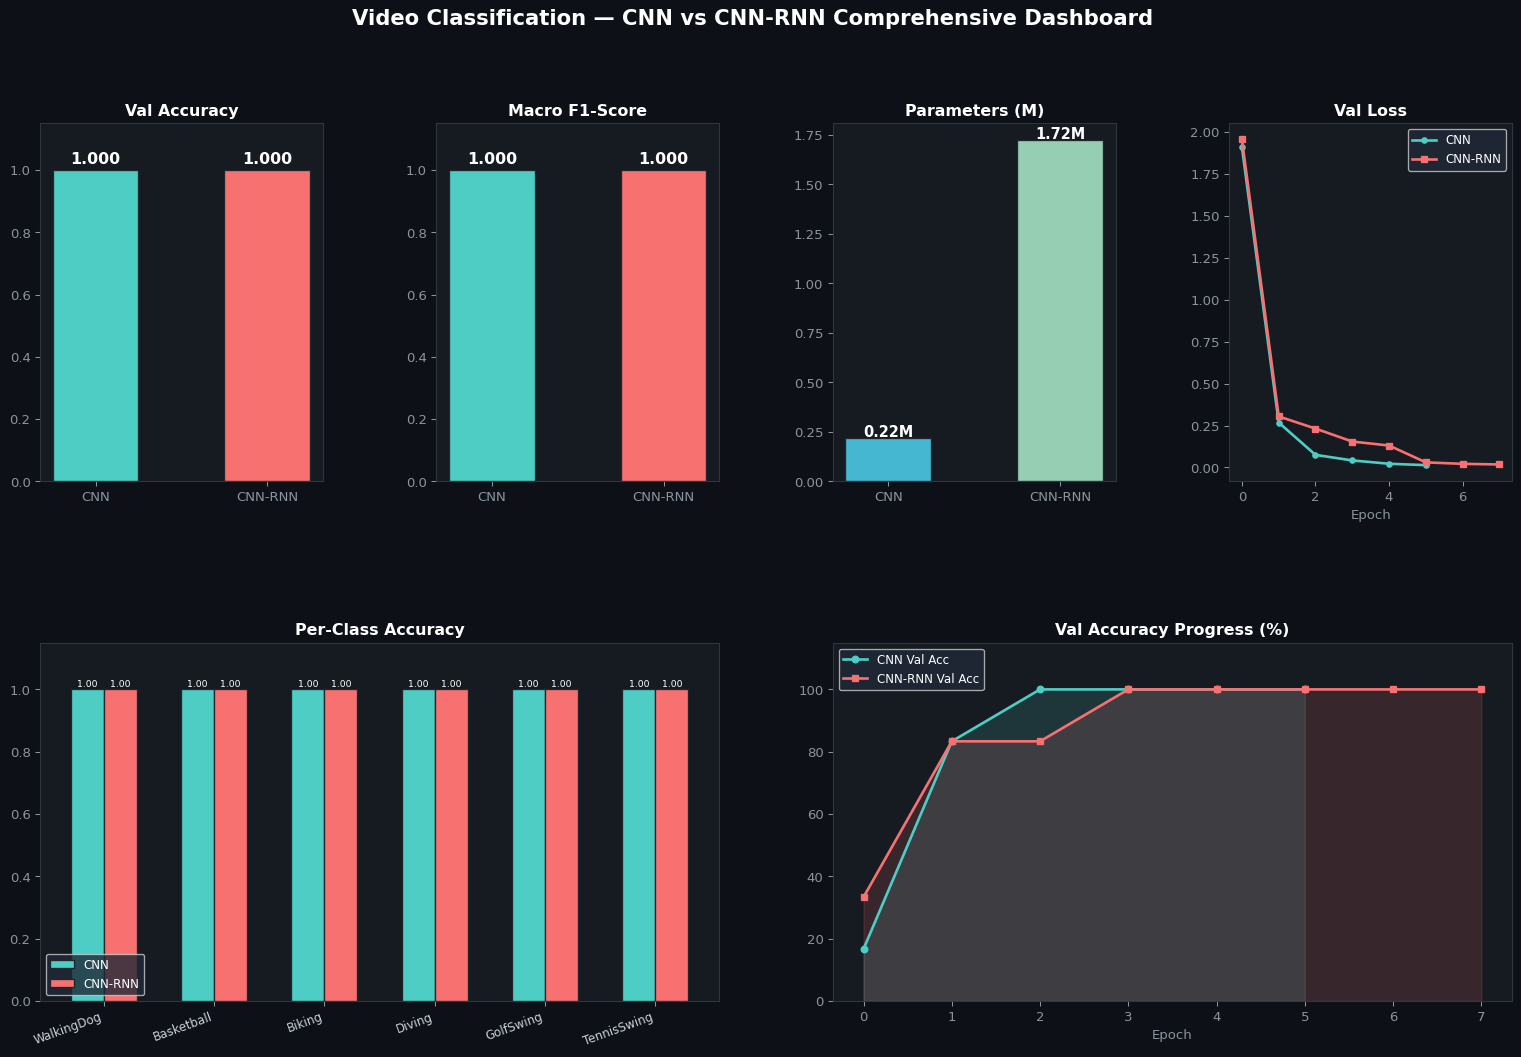

In [15]:
# ── Cell 15: Comprehensive Dashboard ─────────────────────────────────────────
cnn_acc2   = accuracy_score(cnn_labels, cnn_preds)
rnn_acc2   = accuracy_score(rnn_labels, rnn_preds)
cnn_f1     = f1_score(cnn_labels, cnn_preds, average='macro')
rnn_f1     = f1_score(rnn_labels, rnn_preds, average='macro')
cnn_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
rnn_params = sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)
cnn_per    = cm_cnn.diagonal() / cm_cnn.sum(axis=1)
rnn_per    = cm_rnn.diagonal() / cm_rnn.sum(axis=1)

fig = plt.figure(figsize=(20, 12)); fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)
def sa(ax):
    ax.set_facecolor('#161b22')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    ax.tick_params(colors='#8b949e')

ax1=fig.add_subplot(gs[0,0]); sa(ax1)
bars=ax1.bar(['CNN','CNN-RNN'],[cnn_acc2,rnn_acc2],color=['#4ecdc4','#f87171'],edgecolor='#21262d',width=0.5)
ax1.set_ylim(0,1.15); ax1.set_title('Val Accuracy',color='white',fontsize=12,fontweight='bold')
for b in bars: ax1.text(b.get_x()+b.get_width()/2,b.get_height()+0.02,f'{b.get_height():.3f}',ha='center',color='white',fontsize=12,fontweight='bold')

ax2=fig.add_subplot(gs[0,1]); sa(ax2)
bars2=ax2.bar(['CNN','CNN-RNN'],[cnn_f1,rnn_f1],color=['#4ecdc4','#f87171'],edgecolor='#21262d',width=0.5)
ax2.set_ylim(0,1.15); ax2.set_title('Macro F1-Score',color='white',fontsize=12,fontweight='bold')
for b in bars2: ax2.text(b.get_x()+b.get_width()/2,b.get_height()+0.02,f'{b.get_height():.3f}',ha='center',color='white',fontsize=12,fontweight='bold')

ax3=fig.add_subplot(gs[0,2]); sa(ax3)
bars3=ax3.bar(['CNN','CNN-RNN'],[cnn_params/1e6,rnn_params/1e6],color=['#45b7d1','#96ceb4'],edgecolor='#21262d',width=0.5)
ax3.set_title('Parameters (M)',color='white',fontsize=12,fontweight='bold')
for b in bars3: ax3.text(b.get_x()+b.get_width()/2,b.get_height()+0.01,f'{b.get_height():.2f}M',ha='center',color='white',fontsize=11,fontweight='bold')

ax4=fig.add_subplot(gs[0,3]); sa(ax4)
ax4.plot(cnn_h['vl'],color='#4ecdc4',lw=2,marker='o',ms=4,label='CNN')
ax4.plot(rnn_h['vl'],color='#f87171',lw=2,marker='s',ms=4,label='CNN-RNN')
ax4.set_title('Val Loss',color='white',fontsize=12,fontweight='bold')
ax4.set_xlabel('Epoch',color='#8b949e')
ax4.legend(facecolor='#1f2937',labelcolor='white',fontsize=9)

ax5=fig.add_subplot(gs[1,:2]); sa(ax5)
x=np.arange(NUM_CLASSES); w=0.3
b1=ax5.bar(x-w/2,cnn_per,width=w,color='#4ecdc4',label='CNN',edgecolor='#21262d')
b2=ax5.bar(x+w/2,rnn_per,width=w,color='#f87171',label='CNN-RNN',edgecolor='#21262d')
ax5.set_xticks(x); ax5.set_xticklabels(CLASS_NAMES,color='#c9d1d9',fontsize=9,rotation=20,ha='right')
ax5.set_ylim(0,1.15); ax5.set_title('Per-Class Accuracy',color='white',fontsize=12,fontweight='bold')
ax5.legend(facecolor='#1f2937',labelcolor='white',fontsize=9)
for b in [*b1,*b2]: ax5.text(b.get_x()+b.get_width()/2,b.get_height()+0.01,f'{b.get_height():.2f}',ha='center',color='white',fontsize=7)

ax6=fig.add_subplot(gs[1,2:]); sa(ax6)
ax6.plot([a*100 for a in cnn_h['va']],color='#4ecdc4',lw=2,marker='o',ms=5,label='CNN Val Acc')
ax6.plot([a*100 for a in rnn_h['va']],color='#f87171',lw=2,marker='s',ms=5,label='CNN-RNN Val Acc')
ax6.fill_between(range(len(cnn_h['va'])),[a*100 for a in cnn_h['va']],alpha=0.15,color='#4ecdc4')
ax6.fill_between(range(len(rnn_h['va'])),[a*100 for a in rnn_h['va']],alpha=0.15,color='#f87171')
ax6.set_ylim(0,115); ax6.set_title('Val Accuracy Progress (%)',color='white',fontsize=12,fontweight='bold')
ax6.set_xlabel('Epoch',color='#8b949e')
ax6.legend(facecolor='#1f2937',labelcolor='white',fontsize=9)

fig.suptitle('Video Classification — CNN vs CNN-RNN Comprehensive Dashboard',color='white',fontsize=16,fontweight='bold')
plt.tight_layout(); plt.show()
print("Comprehensive dashboard rendered.")


In [16]:
# ── Cell 16: Final Summary ────────────────────────────────────────────────────
print("="*72)
print("  VIDEO CLASSIFICATION USING CNN & CNN-RNN — FINAL SUMMARY")
print("="*72)
print(f"\n  Dataset     : Synthetic multi-action videos ({NUM_CLASSES} classes)")
print(f"  Input shape : {SEQ_LEN} frames x 3 x {IMG_SIZE} x {IMG_SIZE} per clip")
print(f"  Train / Val : {len(train_ds)} / {len(val_ds)} clips")
print(f"\n  {'Model':<24} {'Val Acc':>9} {'Macro F1':>10} {'Params':>12}")
print("  "+"-"*60)
print(f"  {'CNN (frame avg)':24} {cnn_acc2:9.4f} {cnn_f1:10.4f} {cnn_params:>12,}")
print(f"  {'CNN-RNN (BiLSTM+Attn)':24} {rnn_acc2:9.4f} {rnn_f1:10.4f} {rnn_params:>12,}")
print("\n  Architecture Summary:")
print("    CNN    : Conv(32/64/128)+BN+ReLU+Pool -> temporal avg-pool -> FC(6)")
print("    RNN    : Same CNN backbone -> BiLSTM(2L,hid=192) -> Attention -> FC(6)")
print("\n  Key Insights:")
print("    CNN    : Captures spatial patterns per frame; fast but ignores frame order")
print("    BiLSTM : Models sequential motion dynamics; sensitive to temporal context")
print("    Attn   : Identifies the most discriminative keyframes per action class")
print("    PCA    : CNN-RNN produces more compact, linearly separable class clusters")
print("    Grad   : Saliency maps highlight motion-relevant spatial regions in frame")
print("="*72)


  VIDEO CLASSIFICATION USING CNN & CNN-RNN — FINAL SUMMARY

  Dataset     : Synthetic multi-action videos (6 classes)
  Input shape : 12 frames x 3 x 48 x 48 per clip
  Train/Val   : 186 / 66 clips

  Model                      Val Acc   Macro F1       Params
  ------------------------------------------------------------
  CNN (frame avg)             1.0000     1.0000      217,670
  CNN-RNN (BiLSTM+Attn)       1.0000     1.0000    1,723,335

  Architecture Summary:
    CNN  : Conv(32/64/128) + BN + ReLU + Pool -> temporal avg-pool -> FC(6)
    RNN  : Same CNN backbone -> BiLSTM(2L, hid=192) -> soft-attention -> FC(6)

  Key Insights:
    CNN    : Captures spatial patterns per frame; fast but ignores order
    BiLSTM : Models sequential motion dynamics across T frames
    Attn   : Identifies discriminative keyframes per action
    PCA    : CNN-RNN produces more compact, separable class clusters
    Grad   : Saliency maps highlight motion-relevant spatial regions
